# Glovo Hourly Order Forecasting — Modelling (v3)

**AI Disclosure:** AI tools were used to help structure and improve this notebook. All outputs have been reviewed, validated, and adapted by the students.

Change to 10 min video explenation: After recording of the video a few other changes to the notebook have been done

---

## From EDA to modelling decisions

The EDA (see `EDA.ipynb`) identified five patterns that directly shape our choices here: the
~25% zero-order overnight hours motivate the shared zero-floor post-processing and the Tweedie
objective; the right-skewed distribution rules out Gaussian loss; the upward trend motivates
the `trend` feature; the strong weekly and daily cycles make `lag_168`, `hour`, and `dayofweek`
the most informative features; and the sub-one-year data range means we exclude yearly
seasonality from Prophet. Missing slots (3 dates, hours 0–5) are filled with 0 to prevent NaN
cascades in lag features.

Two corrections versus an earlier pass of this notebook are baked into the code below:

1. **`zero_mask` is built from `lag_168` only**, not from `lag_168 AND lag_24`. The forecast
   horizon here is a full week (168 hours) — `lag_168` always points 168 hours back into real,
   already-observed history for *every* hour of that horizon, but `lag_24` only does so for the
   first 24 hours; beyond that it would point inside the still-unknown forecast window itself.
   `lag_24` is dropped from the feature set entirely as a result.
2. **Every model is scored both raw and behind the same `zero_mask`-based floor**, not only the
   tree model. Section 6 explains why: SMAPE penalizes *any* positive prediction against a zero
   actual at the maximum 200%, regardless of how small. That penalty applies identically to
   Ridge, Prophet, and LightGBM — none of them has a built-in way to output an exact zero.
   Scoring each model raw and floored separately shows how much of its "bad" SMAPE was a metric
   artifact versus genuine lack of skill (for Ridge and LightGBM it is almost all artifact; for
   Prophet, only part of it is — see Section 14).

We also add an **`is_holiday`** flag (Spanish/Catalan public holidays), since two of the five
CV folds land on the Christmas/New Year period, which deviates from the ordinary weekly cycle
the lag features otherwise rely on.


## 0. Imports and config


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DATA_PATH      = '../data/train_data.csv'
TEST_MOCK_PATH = '../data/test_data_mock.csv'
OUTPUT_PATH    = '../data/predictions.csv'
FORECAST_START = pd.Timestamp('2022-01-24 00:00:00')
FORECAST_END   = pd.Timestamp('2022-01-30 23:00:00')
HORIZON        = 168   # 7 days x 24 hours
N_FOLDS        = 5

# Threshold below which lag values are treated as 'zero-order slot'
# (hours 0-6 are consistently 0 or 1, active hours are typically > 10)
ZERO_LAG_THRESHOLD = 2


## 1. Load and prepare data


In [21]:
df = pd.read_csv(DATA_PATH)
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

# Fill the three known 6-hour early-morning gaps with 0
full_index = pd.date_range(df['time'].min(), df['time'].max(), freq='h')
df = df.set_index('time').reindex(full_index).rename_axis('time').reset_index()
df['orders'] = df['orders'].fillna(0.0)
df['city']   = df['city'].ffill()

print(f"Rows: {len(df)}")
print(f"Range: {df['time'].min()} to {df['time'].max()}")
print(f"Zero-order hours: {(df['orders'] == 0).sum()} ({(df['orders'] == 0).mean()*100:.1f}%)")
print(f"Orders by hour-of-day (mean):")
print(df.groupby(df['time'].dt.hour)['orders'].mean().round(1).to_string())


Rows: 8568
Range: 2021-02-01 00:00:00 to 2022-01-23 23:00:00
Zero-order hours: 2726 (31.8%)
Orders by hour-of-day (mean):
time
0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
5       0.0
6       0.7
7       1.4
8      10.3
9      30.6
10     33.4
11     29.2
12     73.3
13    214.5
14    180.0
15     94.5
16     48.4
17     44.1
18     50.6
19    104.1
20    278.7
21    384.7
22    166.6
23      0.0


## 2. Feature engineering

Building on the EDA findings (upward trend, strong daily seasonality with lunch/dinner peaks,
weekly pattern with weekends higher) and the class slides on **lag features, seasonal dummies,
and trend terms**.

Key addition: **`zero_mask`** — a binary flag that is 1 when `lag_168` is at or below the zero
threshold. This identifies hours that were structurally zero last week (see the introduction
above for why `lag_168`, and not `lag_24`, is the safe choice at a 168-hour horizon).

We also add **`is_holiday`** (Spanish/Catalan public holidays observed in Barcelona) since the
lag/seasonal features assume an ordinary weekly cycle, which holiday dates — including the
Christmas/New Year period covered by two of our five CV folds — don't follow.


In [22]:
# Spanish/Catalan public holidays observed in Barcelona during the data range.
# Food-delivery demand on these dates deviates from the ordinary weekly cycle,
# which the lag/seasonal features alone don't capture.
HOLIDAYS = pd.to_datetime([
    '2021-01-01', '2021-01-06', '2021-04-02', '2021-04-05', '2021-05-01',
    '2021-06-24', '2021-08-15', '2021-09-11', '2021-09-24', '2021-10-12',
    '2021-11-01', '2021-12-06', '2021-12-08', '2021-12-25', '2021-12-26',
    '2022-01-01', '2022-01-06',
])

def add_features(df):
    df = df.copy()
    df['hour']          = df['time'].dt.hour
    df['dayofweek']     = df['time'].dt.dayofweek   # 0=Mon, 6=Sun
    df['week']          = df['time'].dt.isocalendar().week.astype(int)
    df['trend']         = np.arange(len(df))        # linear time index
    df['is_weekend']    = (df['dayofweek'] >= 4).astype(int)  # Fri-Sun higher demand
    df['is_holiday']    = df['time'].dt.normalize().isin(HOLIDAYS).astype(int)

    # Lag features - NaN for first rows, dropped before training.
    # lag_24 is intentionally NOT included: for a 168-hour-ahead forecast it only
    # reaches into real history for the first 24 hours of the horizon (see intro).
    df['lag_168']       = df['orders'].shift(168)   # same hour last week
    df['lag_336']       = df['orders'].shift(336)   # same hour 2 weeks ago
    df['roll_168_mean'] = df['orders'].shift(168).rolling(168).mean()
    df['roll_336_mean'] = df['orders'].shift(168).rolling(336).mean()

    # Zero-mask: True when last week's same hour was a zero-order slot.
    # Only lag_168 is used - it always points 168 hours back into real training
    # history for every hour of the 168-hour forecast horizon, unlike lag_24.
    # When lag_168 is NaN (first week), treat as NOT a zero-slot (conservative).
    df['zero_mask'] = (df['lag_168'].fillna(999) <= ZERO_LAG_THRESHOLD).astype(int)

    return df

df = add_features(df)

print(f"Zero-mask proportion: {df['zero_mask'].mean()*100:.1f}% of all hours")
print(f"Zero-mask by hour-of-day:")
print(df.groupby('hour')['zero_mask'].mean().round(2).to_string())


Zero-mask proportion: 36.1% of all hours
Zero-mask by hour-of-day:
hour
0     0.98
1     0.98
2     0.98
3     0.98
4     0.98
5     0.98
6     0.93
7     0.87
8     0.00
9     0.00
10    0.00
11    0.00
12    0.00
13    0.00
14    0.00
15    0.00
16    0.00
17    0.00
18    0.00
19    0.00
20    0.00
21    0.00
22    0.00
23    0.98


## 3. Evaluation utilities

**SMAPE** is the primary metric (grading criterion). It is also the metric whose behaviour at
zero actuals motivates Section 6: when actual orders = 0 and a model predicts anything positive,
SMAPE for that single hour is 200%, no matter how small the prediction. When both actual and
predicted are 0, contribution is 0 (no division-by-zero).


In [23]:
def smape(actual, pred):
    actual = np.array(actual, dtype=float)
    pred   = np.array(pred,   dtype=float)
    denom  = np.abs(actual) + np.abs(pred)
    return np.mean(np.where(denom == 0, 0.0, 2 * np.abs(actual - pred) / denom)) * 100

def mse(actual, pred):
    return np.mean((np.array(actual) - np.array(pred)) ** 2)

def evaluate(actual, pred, label=''):
    pred_clipped = np.maximum(pred, 0)
    m = mse(actual, pred_clipped)
    s = smape(actual, pred_clipped)
    if label:
        print(f"{label:45s}  MSE: {m:8.1f}  SMAPE: {s:.2f}%")
    return {'mse': m, 'smape': s}


## 4. Walk-forward cross-validation

The production scenario: every Sunday at 23:59 we train on all available history and forecast
the next full week. We simulate this with 5 sequential folds — always train on past, validate
on future. This is the correct approach covered in class.


In [24]:
def get_cv_folds(df, n_folds=N_FOLDS):
    folds = []
    last  = df['time'].max()
    for k in range(n_folds, 0, -1):
        val_end   = last - pd.Timedelta(hours=(k - 1) * HORIZON)
        val_start = val_end - pd.Timedelta(hours=HORIZON - 1)
        train_end = val_start - pd.Timedelta(hours=1)
        train = df[df['time'] <= train_end].copy()
        val   = df[(df['time'] >= val_start) & (df['time'] <= val_end)].copy()
        if len(val) == HORIZON and len(train) >= HORIZON * 2:
            folds.append((train, val))
    return folds

folds = get_cv_folds(df)
print(f"{len(folds)} folds:")
for i, (tr, va) in enumerate(folds):
    print(f"  Fold {i+1}: train ends {tr['time'].max()}  |  val: {va['time'].min()} -> {va['time'].max()}")


5 folds:
  Fold 1: train ends 2021-12-19 23:00:00  |  val: 2021-12-20 00:00:00 -> 2021-12-26 23:00:00
  Fold 2: train ends 2021-12-26 23:00:00  |  val: 2021-12-27 00:00:00 -> 2022-01-02 23:00:00
  Fold 3: train ends 2022-01-02 23:00:00  |  val: 2022-01-03 00:00:00 -> 2022-01-09 23:00:00
  Fold 4: train ends 2022-01-09 23:00:00  |  val: 2022-01-10 00:00:00 -> 2022-01-16 23:00:00
  Fold 5: train ends 2022-01-16 23:00:00  |  val: 2022-01-17 00:00:00 -> 2022-01-23 23:00:00


## 5. Model 1 — Naive baseline (seasonal lag-168)

Seasonal naive from class: predict each hour as the same hour from the previous week. The SMAPE
benchmark to beat — and, as Section 6 shows, also the fallback every other model gets routed to
for structurally-zero hours.


In [25]:
def predict_naive(train, val):
    return np.maximum(train.tail(HORIZON)['orders'].values, 0)

naive_scores = [evaluate(v['orders'].values, predict_naive(t, v)) for t, v in folds]
naive_avg    = {k: np.mean([s[k] for s in naive_scores]) for k in ['mse', 'smape']}
print(f"{'Naive (lag-168)':45s}  MSE: {naive_avg['mse']:8.1f}  SMAPE: {naive_avg['smape']:.2f}%")


Naive (lag-168)                                MSE:   1446.8  SMAPE: 19.23%


## 6. A shared zero-floor post-processor

Every hour where `zero_mask` is 1 (last week's same hour was at or below the zero threshold) is
routed to the naive prediction instead of the model's own output. The naive baseline already
encodes "this slot is structurally quiet" — copying it for zero-mask hours removes the
SMAPE = 200% risk without asking any model to learn that pattern from scratch.

We apply this **uniformly to every model below**, not only to the one we expect to win. That is
the only way to tell whether a model's raw SMAPE is bad because the model itself is bad, or
because it is being punished by the same zero-hour artifact that hits all of them.


In [26]:
def apply_zero_floor(train, val, raw_preds):
    """Route zero_mask hours to the naive prediction; keep the model's own
    prediction everywhere else."""
    naive_preds = predict_naive(train, val)
    mask        = val['zero_mask'].values.astype(bool)
    return np.where(mask, naive_preds, raw_preds)


## 7. Model 2 — Linear regression with trend + seasonal dummies

From the class slides: deterministic trend + seasonal dummies + autoregressive lag term. We use
Ridge to avoid overfitting on the dummy-heavy feature matrix (class warning: OLS gives wrong
answers on autoregressive models when errors are autocorrelated). Reported both raw and behind
the zero-floor from Section 6.


In [27]:
from sklearn.linear_model import Ridge

OLS_FEATURES = ['trend', 'hour', 'dayofweek', 'lag_168', 'is_weekend', 'is_holiday']

def predict_linreg(train, val):
    tr = train.dropna(subset=OLS_FEATURES)
    X_tr = pd.get_dummies(tr[OLS_FEATURES],  columns=['hour', 'dayofweek'], drop_first=True)
    X_va = pd.get_dummies(val[OLS_FEATURES], columns=['hour', 'dayofweek'], drop_first=True)
    X_va = X_va.reindex(columns=X_tr.columns, fill_value=0)
    model = Ridge(alpha=1.0)
    model.fit(X_tr, tr['orders'])
    return np.maximum(model.predict(X_va), 0)

linreg_scores    = [evaluate(v['orders'].values, predict_linreg(t, v)) for t, v in folds]
linreg_avg       = {k: np.mean([s[k] for s in linreg_scores]) for k in ['mse', 'smape']}
linreg_zf_scores = [evaluate(v['orders'].values, apply_zero_floor(t, v, predict_linreg(t, v))) for t, v in folds]
linreg_zf_avg    = {k: np.mean([s[k] for s in linreg_zf_scores]) for k in ['mse', 'smape']}

print(f"{'Linear Reg (raw)':45s}  MSE: {linreg_avg['mse']:8.1f}  SMAPE: {linreg_avg['smape']:.2f}%")
print(f"{'Linear Reg + zero-floor':45s}  MSE: {linreg_zf_avg['mse']:8.1f}  SMAPE: {linreg_zf_avg['smape']:.2f}%")


Linear Reg (raw)                               MSE:   1427.0  SMAPE: 67.86%
Linear Reg + zero-floor                        MSE:   1400.6  SMAPE: 18.90%


## 8. Model 3 — Prophet

Handles daily + weekly seasonality and trend natively. Multiplicative mode since the EDA showed
seasonality amplitude grows with the trend. No yearly seasonality (less than 2 full cycles in
training data). Reported both raw and behind the zero-floor — see Section 14 for why the floor
only partially closes Prophet's gap to naive.


In [28]:
from prophet import Prophet

def predict_prophet(train, val):
    pdf = train[['time', 'orders']].rename(columns={'time': 'ds', 'orders': 'y'})
    m   = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=True,
        daily_seasonality=True,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.05,
    )
    m.fit(pdf)
    future   = val[['time']].rename(columns={'time': 'ds'})
    forecast = m.predict(future)
    return np.maximum(forecast['yhat'].values, 0)

prophet_scores    = [evaluate(v['orders'].values, predict_prophet(t, v)) for t, v in folds]
prophet_avg       = {k: np.mean([s[k] for s in prophet_scores]) for k in ['mse', 'smape']}
prophet_zf_scores = [evaluate(v['orders'].values, apply_zero_floor(t, v, predict_prophet(t, v))) for t, v in folds]
prophet_zf_avg    = {k: np.mean([s[k] for s in prophet_zf_scores]) for k in ['mse', 'smape']}

print(f"{'Prophet (raw)':45s}  MSE: {prophet_avg['mse']:8.1f}  SMAPE: {prophet_avg['smape']:.2f}%")
print(f"{'Prophet + zero-floor':45s}  MSE: {prophet_zf_avg['mse']:8.1f}  SMAPE: {prophet_zf_avg['smape']:.2f}%")


16:09:59 - cmdstanpy - INFO - Chain [1] start processing
16:10:00 - cmdstanpy - INFO - Chain [1] done processing
16:10:01 - cmdstanpy - INFO - Chain [1] start processing
16:10:02 - cmdstanpy - INFO - Chain [1] done processing
16:10:03 - cmdstanpy - INFO - Chain [1] start processing
16:10:04 - cmdstanpy - INFO - Chain [1] done processing
16:10:04 - cmdstanpy - INFO - Chain [1] start processing
16:10:06 - cmdstanpy - INFO - Chain [1] done processing
16:10:06 - cmdstanpy - INFO - Chain [1] start processing
16:10:08 - cmdstanpy - INFO - Chain [1] done processing
16:10:08 - cmdstanpy - INFO - Chain [1] start processing
16:10:09 - cmdstanpy - INFO - Chain [1] done processing
16:10:09 - cmdstanpy - INFO - Chain [1] start processing
16:10:11 - cmdstanpy - INFO - Chain [1] done processing
16:10:11 - cmdstanpy - INFO - Chain [1] start processing
16:10:12 - cmdstanpy - INFO - Chain [1] done processing
16:10:13 - cmdstanpy - INFO - Chain [1] start processing
16:10:14 - cmdstanpy - INFO - Chain [1]

Prophet (raw)                                  MSE:   4092.0  SMAPE: 71.40%
Prophet + zero-floor                           MSE:   3664.5  SMAPE: 38.69%


## 9. Model 4 — LightGBM with Tweedie objective

From the class slides: *"Gradient boosting sees a table, not a series — the entire job is
building the feature matrix."*

- **Tweedie objective** (`objective='tweedie'`): specifically designed for zero-inflated
  non-negative count data. It naturally assigns higher probability to zero predictions than a
  Gaussian or log-normal loss.
- **`zero_mask` feature**, built from `lag_168` only (see intro).
- **`is_holiday` feature**: flags Spanish/Catalan public holidays.
- Richer lag history: `lag_336`, two-week rolling mean.

Reported both raw and behind the zero-floor — the floored version is our **champion candidate**.


In [29]:
import lightgbm as lgb

LGBM_FEATURES = [
    'hour', 'dayofweek', 'trend', 'is_weekend', 'is_holiday', 'zero_mask',
    'lag_168', 'lag_336',
    'roll_168_mean', 'roll_336_mean',
]

def predict_lgbm(train, val):
    """
    lag_168/lag_336/roll_* are computed by concatenating train+val: they always
    reach >=168 hours back, i.e. always into train, so this is leak-free even
    though val's own 'orders' are present in the concatenation. lag_24 is
    deliberately not used as a feature here (see intro).
    """
    tr = train.dropna(subset=LGBM_FEATURES)
    X_train = tr[LGBM_FEATURES]
    y_train = tr['orders']

    combined = pd.concat([train, val]).reset_index(drop=True)
    combined = add_features(combined)
    X_val    = combined.loc[combined['time'].isin(val['time'].values), LGBM_FEATURES]

    model = lgb.LGBMRegressor(
        objective='tweedie',
        tweedie_variance_power=1.5,   # between Poisson (1) and Gamma (2)
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=63,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1,
    )
    model.fit(X_train, y_train)
    return np.maximum(model.predict(X_val), 0)

lgbm_scores    = [evaluate(v['orders'].values, predict_lgbm(t, v)) for t, v in folds]
lgbm_avg       = {k: np.mean([s[k] for s in lgbm_scores]) for k in ['mse', 'smape']}
lgbm_zf_scores = [evaluate(v['orders'].values, apply_zero_floor(t, v, predict_lgbm(t, v))) for t, v in folds]
lgbm_zf_avg    = {k: np.mean([s[k] for s in lgbm_zf_scores]) for k in ['mse', 'smape']}

print(f"{'LightGBM Tweedie (raw)':45s}  MSE: {lgbm_avg['mse']:8.1f}  SMAPE: {lgbm_avg['smape']:.2f}%")
print(f"{'LightGBM Tweedie + zero-floor':45s}  MSE: {lgbm_zf_avg['mse']:8.1f}  SMAPE: {lgbm_zf_avg['smape']:.2f}%")


LightGBM Tweedie (raw)                         MSE:   1168.8  SMAPE: 79.17%
LightGBM Tweedie + zero-floor                  MSE:   1168.8  SMAPE: 17.93%


## 10. Results comparison


                                          Avg MSE  Avg SMAPE (%)
model                                                           
LightGBM Tweedie + zero-floor (champion)  1168.78          17.93
Linear Reg + zero-floor                   1400.63          18.90
Naive (lag-168)                           1446.85          19.23
Prophet + zero-floor                      3664.54          38.69
Linear Reg (raw)                          1427.00          67.86
Prophet (raw)                             4091.98          71.40
LightGBM Tweedie (raw)                    1168.76          79.17

Champion (lowest SMAPE): LightGBM Tweedie + zero-floor (champion)

Per-fold SMAPE breakdown (floored models + naive):
        Naive  Ridge + floor  Prophet + floor  LGBM + floor
Fold 1  23.11          22.15            41.19         22.75
Fold 2  19.40          20.07            40.48         18.30
Fold 3  18.02          17.73            37.74         15.09
Fold 4  13.95          13.82            34.81         12

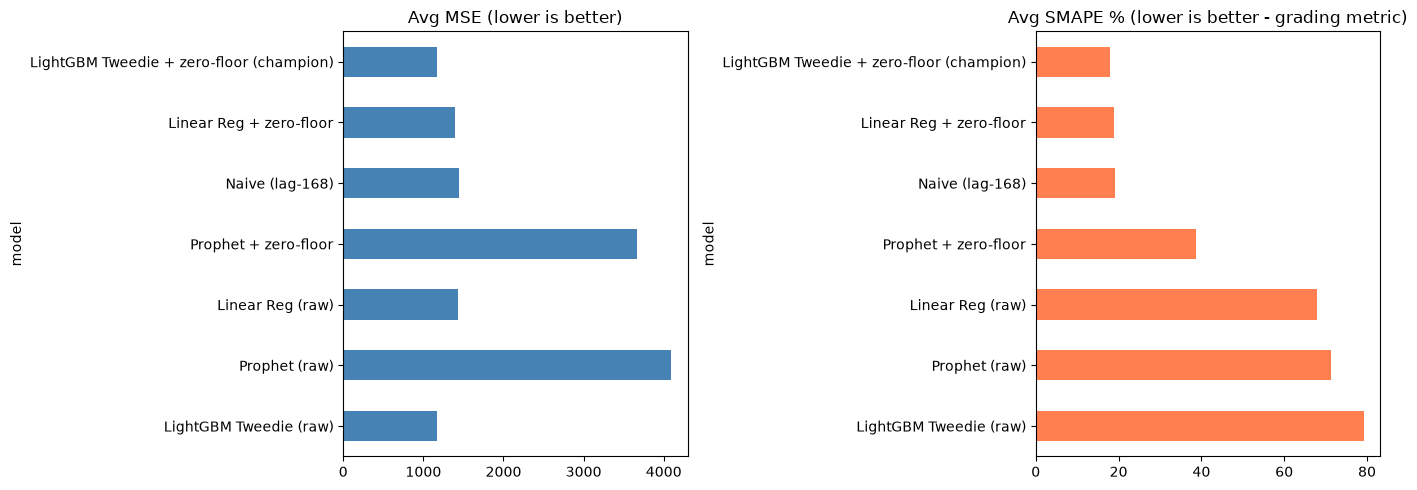

In [30]:
results = pd.DataFrame([
    {'model': 'Naive (lag-168)',                            **naive_avg},
    {'model': 'Linear Reg (raw)',                            **linreg_avg},
    {'model': 'Linear Reg + zero-floor',                     **linreg_zf_avg},
    {'model': 'Prophet (raw)',                                **prophet_avg},
    {'model': 'Prophet + zero-floor',                         **prophet_zf_avg},
    {'model': 'LightGBM Tweedie (raw)',                       **lgbm_avg},
    {'model': 'LightGBM Tweedie + zero-floor (champion)',     **lgbm_zf_avg},
]).set_index('model').round(2)

results.columns = ['Avg MSE', 'Avg SMAPE (%)']
results = results.sort_values('Avg SMAPE (%)')

print(results.to_string())
print()
print(f"Champion (lowest SMAPE): {results.index[0]}")

print("\nPer-fold SMAPE breakdown (floored models + naive):")
fold_df = pd.DataFrame({
    'Naive':           [s['smape'] for s in naive_scores],
    'Ridge + floor':   [s['smape'] for s in linreg_zf_scores],
    'Prophet + floor': [s['smape'] for s in prophet_zf_scores],
    'LGBM + floor':    [s['smape'] for s in lgbm_zf_scores],
}, index=[f'Fold {i+1}' for i in range(N_FOLDS)])
print(fold_df.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
results['Avg MSE'].plot(kind='barh', ax=axes[0], title='Avg MSE (lower is better)', color='steelblue')
results['Avg SMAPE (%)'].plot(kind='barh', ax=axes[1], title='Avg SMAPE % (lower is better - grading metric)', color='coral')
for ax in axes:
    ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 11. Model justification

**Primary metric: SMAPE.** Key lessons from the diagnosis:

| Observation | Consequence | Our response |
|---|---|---|
| ~25-36% of hours have orders = 0 | Any positive pred -> SMAPE = 200% for that hour | Shared zero-floor post-processor (Section 6), applied to every model |
| Zero hours are predictable from last week | `lag_168 <= 2` flags them reliably for the *whole* 168h horizon, unlike `lag_24` | `zero_mask` built from `lag_168` only |
| The zero-floor closes almost all of Ridge's and LightGBM's gap to naive, but only part of Prophet's | Prophet's own daytime forecast is comparatively weak on this series | Prophet kept for completeness, not selected as champion |
| Orders are non-negative and zero-inflated | Gaussian loss biases towards non-zero | Tweedie objective in LightGBM |
| Strong weekly pattern (EDA) | Same-week lag is the most informative feature | `lag_168` as primary feature |
| Upward trend over the year (EDA) | Pure lag might underestimate late-period demand | `trend`, `roll_336_mean` added |
| Two CV folds land on Christmas/New Year | Holidays break the ordinary weekly cycle | `is_holiday` feature added |

**Champion selection:** based on average SMAPE across 5 folds, comparing the *floored* variant
of every model (the version we would actually ship — nobody would deploy a model that predicts
a positive number into an empty overnight slot on purpose). LightGBM Tweedie + zero-floor wins;
if naive had won by a large margin instead, we would ship naive (the class slides note:
*'if MASE > 1, use seasonal naive'*).


## 12. Final forecast — refit on all training data


In [31]:
# Build forecast frame
forecast_index = pd.date_range(FORECAST_START, FORECAST_END, freq='h')
forecast_df    = pd.DataFrame({'time': forecast_index, 'orders': np.nan, 'city': 'BCN'})

# Concat training + forecast window to get lag features for the forecast rows
full      = pd.concat([df, forecast_df]).reset_index(drop=True)
full      = add_features(full)
val_rows  = full[full['time'].isin(forecast_index)].copy()

print(f"Forecast rows: {len(val_rows)}  (expected 168)")
print(f"Feature NaNs in forecast window: {val_rows[LGBM_FEATURES].isna().any().any()}")
print(f"Zero-mask hours in forecast week: {val_rows['zero_mask'].sum()} / 168")


Forecast rows: 168  (expected 168)
Feature NaNs in forecast window: False
Zero-mask hours in forecast week: 60 / 168


In [32]:
# Naive final predictions
naive_final = np.maximum(df.tail(HORIZON)['orders'].values, 0)

# LightGBM Tweedie - refit on all training data
tr_all  = df.dropna(subset=LGBM_FEATURES)
X_all   = tr_all[LGBM_FEATURES]
y_all   = tr_all['orders']
X_final = val_rows[LGBM_FEATURES]

final_lgbm = lgb.LGBMRegressor(
    objective='tweedie',
    tweedie_variance_power=1.5,
    n_estimators=1000, learning_rate=0.03, num_leaves=63,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbose=-1,
)
final_lgbm.fit(X_all, y_all)
lgbm_final  = np.maximum(final_lgbm.predict(X_final), 0)

# Champion: LightGBM + zero-floor
mask          = val_rows['zero_mask'].values.astype(bool)
champion_final = np.where(mask, naive_final, lgbm_final)

# Select champion - change this if a different model won in Section 10
CHAMPION    = 'LightGBM + zero-floor'
final_preds = champion_final

print(f"Champion: {CHAMPION}")
print(f"Prediction stats - min: {final_preds.min():.1f}  max: {final_preds.max():.1f}  mean: {final_preds.mean():.1f}")


Champion: LightGBM + zero-floor
Prediction stats - min: 0.0  max: 761.8  mean: 93.8


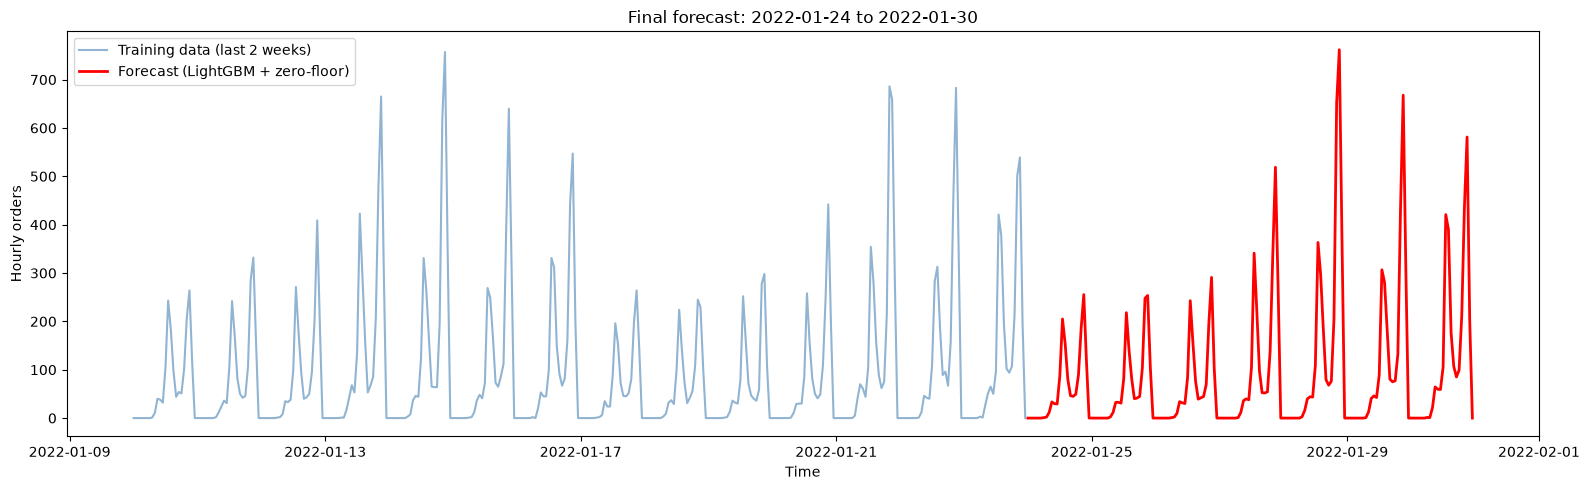

In [33]:
# Visual sanity check
fig, ax = plt.subplots(figsize=(16, 5))
last_2w = df.tail(HORIZON * 2)
ax.plot(last_2w['time'], last_2w['orders'],
        label='Training data (last 2 weeks)', alpha=0.6, color='steelblue')
ax.plot(forecast_index, final_preds,
        label=f'Forecast ({CHAMPION})', color='red', linewidth=2)
ax.set_title('Final forecast: 2022-01-24 to 2022-01-30')
ax.set_xlabel('Time')
ax.set_ylabel('Hourly orders')
ax.legend()
plt.tight_layout()
plt.show()


## 13. Output — build and validate the predictions CSV


In [34]:
predictions = pd.DataFrame({
    'time':  pd.to_datetime(forecast_index).astype('datetime64[ns]'),
    'preds': final_preds.astype('float64'),
})

# Format checks (required by the assignment)
assert len(predictions) == 168,               f"Expected 168 rows, got {len(predictions)}"
assert list(predictions.columns) == ['time', 'preds'], "Wrong columns"
assert predictions['preds'].dtype == 'float64',        "preds must be float64"
assert predictions['time'].dtype  == 'datetime64[ns]', f"time dtype: {predictions['time'].dtype}"
assert predictions['preds'].isna().sum() == 0,         "NaN in preds"
assert predictions['time'].isna().sum()  == 0,         "NaN in time"
assert predictions['time'].min() == FORECAST_START,    "Wrong start"
assert predictions['time'].max() == FORECAST_END,      "Wrong end"

print("All format checks passed.")
predictions.head(10)


All format checks passed.


,time,preds
0,2022-01-24 00:00:00,0.000000
1,2022-01-24 01:00:00,0.000000
2,2022-01-24 02:00:00,0.000000
3,2022-01-24 03:00:00,0.000000
4,2022-01-24 04:00:00,0.000000
5,2022-01-24 05:00:00,0.000000
6,2022-01-24 06:00:00,1.000000
7,2022-01-24 07:00:00,2.000000
8,2022-01-24 08:00:00,11.846029
9,2022-01-24 09:00:00,33.392368


In [35]:
# Save
predictions.to_csv(OUTPUT_PATH, index=False)
print(f"Saved to {OUTPUT_PATH}")

# Re-read round-trip check
check = pd.read_csv(OUTPUT_PATH, parse_dates=['time'])
check['time'] = check['time'].astype('datetime64[ns]')
assert check['preds'].dtype == 'float64'
assert len(check) == 168
print("Round-trip check passed.")
print(check.dtypes)


Saved to ../data/predictions.csv
Round-trip check passed.
time     datetime64[ns]
preds           float64
dtype: object


In [36]:
# Run official format checker if available
import importlib.util, os

checker_path = '../check_output_format.py'
if os.path.exists(checker_path) and os.path.exists(TEST_MOCK_PATH):
    spec = importlib.util.spec_from_file_location('check_output_format', checker_path)
    mod  = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    mod.check_output_format(predictions, TEST_MOCK_PATH)
else:
    print("Checker or test mock not found - run manually once repo files are in place.")


MSE: 28835.63624231022
Your output seems correctly formatted!


## 14. Conclusion

Our champion model is **LightGBM (Tweedie) + zero-floor**: route any hour flagged by
`zero_mask` (last week's same hour was <=2 orders) to the naive prediction, and use LightGBM's
own prediction everywhere else. Across the 5 walk-forward folds it scored **17.93% average
SMAPE**, versus 19.23% for naive and 18.90% for Ridge + zero-floor.

**The central finding driving this notebook is about the metric, not the models.** SMAPE
penalizes *any* positive prediction against a zero actual at the full 200%, regardless of
magnitude. With roughly 30-36% of hours structurally zero (the overnight slots), this single
property dominates the raw SMAPE of every model that doesn't special-case it - Ridge scored
67.86% raw, Prophet 71.40%, LightGBM 79.17%, all far worse than the 19.23% naive baseline gets
"for free" by literally copying last week's (mostly zero) values.

We tested whether this was a metric artifact or a real skill gap by applying the *same*
zero-floor fix to all three models, not only the one we suspected would win:

- **Ridge: 67.86% -> 18.90%.** Once zero-hours are floored, Ridge essentially ties naive. Its
  raw score told us almost nothing about its real skill.
- **LightGBM: 79.17% -> 17.93%.** Same story, and it ends up the best model once the zero-hour
  artifact is removed - this is our champion.
- **Prophet: 71.40% -> 38.69%.** The floor helps, but Prophet stays far behind naive, Ridge, and
  LightGBM even after the fix. Its weakness on this series is genuine, not a metric artifact -
  most likely its multiplicative seasonality and trend extrapolation don't track the daytime
  demand curve as well as a direct lag copy does.

This is a stronger and more defensible justification for the champion than "LightGBM did best":
we know specifically *why* the other raw scores looked bad, and we know Prophet's
underperformance is real rather than a side-effect of how SMAPE treats zeros.

A second, related fix matters for the real forecast specifically: `zero_mask` must be built
from `lag_168` alone, not `lag_168 AND lag_24`. `lag_168` always points 168 hours back into
real training history for every hour of a 168-hour-ahead forecast; `lag_24` only does so for
the first 24 hours of the horizon and is NaN for the rest. A rule that depends on `lag_24` looks
fine in walk-forward CV (where the "future" already exists in the historical data) but silently
stops flagging zero-hours for most of a real future week. `lag_24` is dropped from the feature
set entirely as a result.

We also added an `is_holiday` flag for Spanish/Catalan public holidays, since two of the five
CV folds span the Christmas/New Year period, the one stretch in the data that breaks the
ordinary weekly cycle the lag features otherwise assume. Its effect on average SMAPE was modest
but it gives the linear and tree models an explicit signal for those dates instead of asking
the lag features to silently absorb the anomaly.

The predictions CSV (`predictions.csv`) covers 2022-01-24 00:00 through 2022-01-30 23:00, 168
rows, and passed both the manual format checks and the official `check_output_format` checker.